# Inspecting WaPOR through time

* **Products used:** 
[s2_l2a](https://explorer.digitalearth.africa/s2_l2a), 
[crop_mask](https://explorer.digitalearth.africa/crop_mask)

## Background
The **Wa**ter **P**roductivity through **O**pen access of **R**emotely sensed derived data (WaPOR) monitors and reports on agricultural water productivity through biophysical measures with a focus on Africa and the Near East. This information assists partner countries improve land and water productivity in both rainfed and irrigated agriculture ([Peiser et al. 2017](https://openknowledge.fao.org/items/cdacf817-c13a-4859-b681-a4bdc20c065c)). 

WaPOR provides numerous datasets related to vegetation productivity and water consumption, and associated meteorological and physical conditions such as soil moisture and precipitation. These datasets can be combined with Digital Earth Africa products, services, and workflows for numerous applications including:
   * Monitoring the water use efficiency of crops
   * Mapping irrigated areas
   * Estimating crop water requirements
   * Irrigation scheduling and budgeting

## Description
This notebook provides and introduction to WaPOR data and nomenclature, and demonstrates loading and plotting.

1. First, we explore the datasets available and how they are labelled.
2. Then, we download and plot annual data.
3. Finally, we download and plot dekadal (10 day temporal frequency) data.

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages that are used for the analysis.

Use standard import commands; some are shown below. 
Begin with any `iPython` magic commands, followed by standard Python packages, then any additional functionality you need from the `Tools` package.

In [1]:
#!pip install wapordl

In [2]:
#!pip uninstall Tools -y
#!pip install ../../Tools

In [3]:
import datetime as dt
import datacube
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import mpl_toolkits.axisartist as AA
import pandas as pd
import rioxarray
import xarray as xr

from datacube.utils.masking import mask_invalid_data
from mpl_toolkits.axes_grid1 import host_subplot
from deafrica_tools.bandindices import calculate_indices
from deafrica_tools.datahandling import load_ard
from deafrica_tools.load_wapor import get_all_WaPORv3_mapsets, get_WaPORv3_info, load_wapor_ds
from deafrica_tools.plotting import display_map
from deafrica_tools.temporal import temporal_statistics, xr_phenology
from odc.algo import xr_reproject
from wapordl import wapor_map

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [4]:
dc = datacube.Datacube(app="WaPOR")

### Analysis parameters

The cell below specifies:
* The region/area of interest. This can also be a `.geojson` file
* The folder where the downloaded data will be stored. If you are using this script repeatedly, it is recommended you empty this folder from time to time to reduce storage on the Sandbox volume. 

In [5]:
region =  [31.30, 30.70, 31.40, 30.80] #xmin, ymin, xmax, ymax
folder = "Supplementary_data/WaPOR" # folder that the data will be sent to

As for the loading data notebook, this demonstration notebook loads an area of cropland in the Nile Delta, Egypt.

In [6]:
display_map(x=(region[0], region[2]), y=(region[1], region[3]))

## Load Sentinel-2 imagery

We will use surface reflectance data to calculate indices for an initial assessment of crop phenology, so we load Sentinel-2 data for this.

In [7]:
period = ["2022-01-01", "2023-12-31"]

query = {
    "y": (region[1],region[3]),
    "x": (region[0],region[2]),
    "time": period,
    "measurements": ["red", "green", "blue", "nir"],
    "resolution": (-20, 20),
    "output_crs": "epsg:6933", #match wapor
    "group_by": "solar_day",
}

# Load available data from Sentinel-2
ds = load_ard(
    dc=dc,
    products=["s2_l2a"],
    **query,
)

ds

Using pixel quality parameters for Sentinel 2
Finding datasets
    s2_l2a
Applying pixel quality/cloud mask
Loading 148 time steps


/usr/local/lib/python3.10/dist-packages/rasterio/warp.py:344: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _reproject(


<xarray.Dataset>
Dimensions:      (time: 148, y: 551, x: 483)
Coordinates:
  * time         (time) datetime64[ns] 2022-01-03T08:41:33 ... 2023-12-29T08:...
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
    spatial_ref  int32 6933
Data variables:
    red          (time, y, x) float32 433.0 421.0 440.0 ... 392.0 363.0 490.0
    green        (time, y, x) float32 783.0 753.0 785.0 ... 583.0 682.0 714.0
    blue         (time, y, x) float32 559.0 551.0 552.0 ... 287.0 282.0 340.0
    nir          (time, y, x) float32 4.208e+03 3.948e+03 ... 4.277e+03
Attributes:
    crs:           epsg:6933
    grid_mapping:  spatial_ref

## Load the cropland mask

In this notebook, we are interested in the phenology of crops. Therefore, we limit our area to cropland only to eliminate the effect of other land cover classes. We use the Digital Earth Africa cropland mask to do this below.

Firstly, we load the cropland mask for the area of interest.

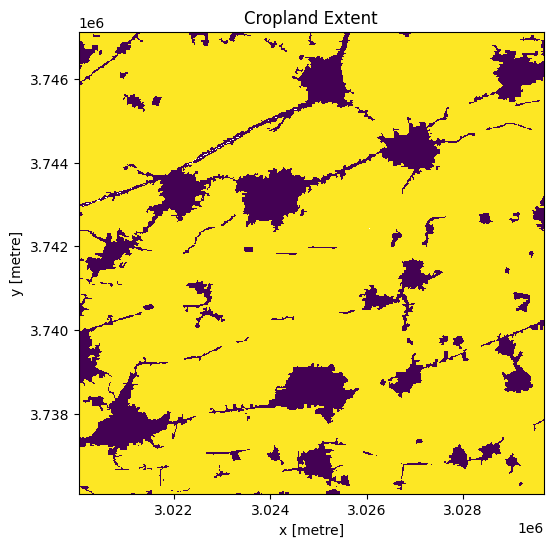

In [8]:
cm = dc.load(
    product="crop_mask",
    time=("2019"),
    measurements="filtered",
    resampling="nearest",
    like=ds.geobox,
).filtered.squeeze()

cm.where(cm < 255).plot.imshow(
    add_colorbar=False, figsize=(6, 6)
)  # we filter to <255 to omit missing data
plt.title("Cropland Extent");

Next, we mask the Sentinel-2 data, `ds`, to cropland areas.

In [9]:
ds = ds.where(cm == 1)

We will use the Enhanced Vegetation Index (EVI) to get an intial picture of phenology. This is a preferred index because it is more sensitive at high levels of greenness, which are observed in densely planted irrigated crops, which we are looking at here. We can therefore better identify progression of the crop season with EVI than with other indices.

In [10]:
ds = calculate_indices(ds, index='EVI', satellite_mission="s2")

The cell below resamples the EVI timeseries to regular 10 day intervals.

In [11]:
resample_period = "10D"
window = 4

veg_smooth = (
    ds['EVI']
    .resample(time=resample_period)
    .median()
    .rolling(time=window, min_periods=1)
    .mean()
)

In [ ]:
## Inspect phenology

Plotting the EVI timeseries over 

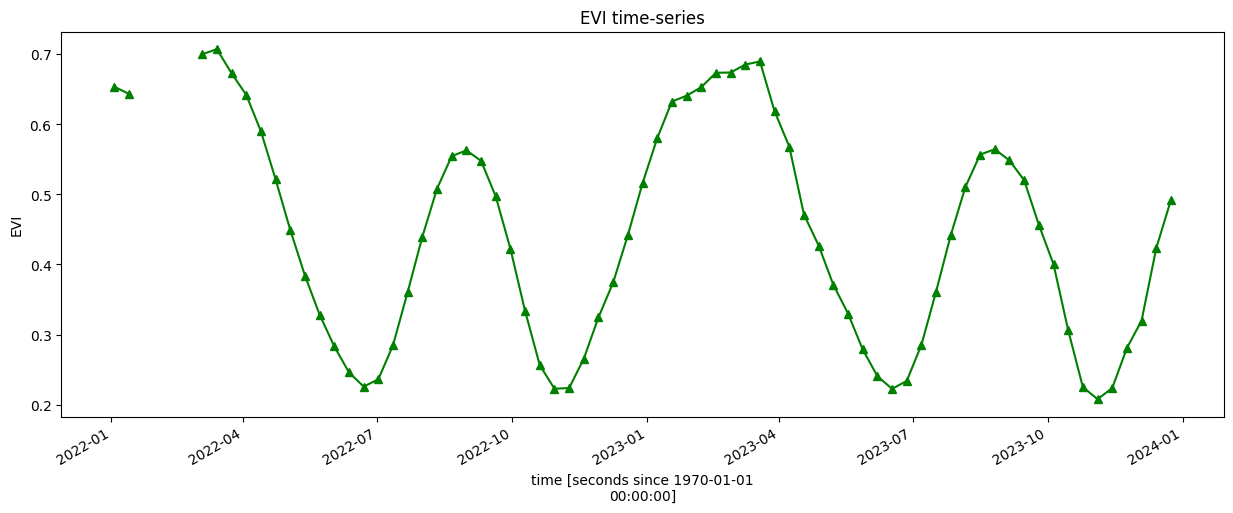

In [12]:
veg_smooth_1D = veg_smooth.mean(["x", "y"])
veg_smooth_1D.plot.line("b-^", figsize=(15, 5), color='green')
_max = veg_smooth_1D.max()
_min = veg_smooth_1D.min()

plt.title("EVI time-series")
plt.ylabel('EVI');

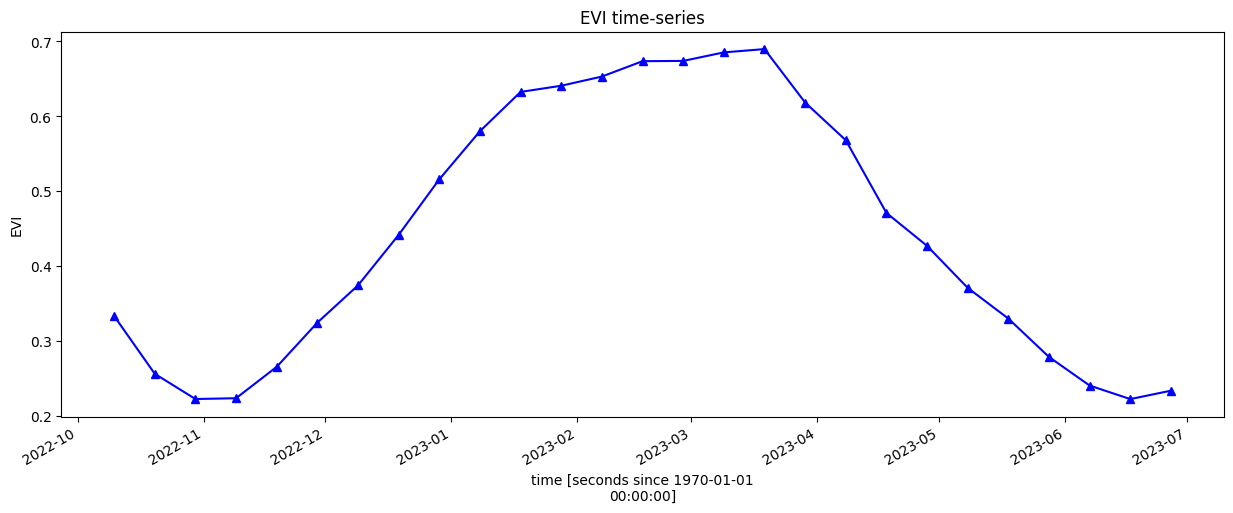

In [13]:
veg_smooth_1D = veg_smooth.mean(["x", "y"]).sel(time=slice('2022-10', '2023-06'))
veg_smooth_1D.plot.line("b-^", figsize=(15, 5))
_max = veg_smooth_1D.max()
_min = veg_smooth_1D.min()

plt.title("EVI time-series")
plt.ylabel('EVI');

In [14]:
basic_pheno_stats = [
    "SOS",
    "vSOS",
    "POS",
    "vPOS",
    "EOS",
    "vEOS",
    "Trough",
    "LOS",
    "AOS",
    "ROG",
    "ROS",
]
method_sos = "first"
method_eos = "last"

In [15]:
years = veg_smooth_1D.groupby("time.year")

# store results in dict
pheno_results = {}

# loop through years and calculate phenology
for y, year in years:
    # calculate stats
    stats = xr_phenology(
        year,
        method_sos=method_sos,
        method_eos=method_eos,
        stats=basic_pheno_stats,
        verbose=False,
    )
    # add results to dict
    pheno_results[str(y)] = stats

df_dict = {}
for key, value in pheno_results.items():
    df_dict_1 = {}
    for b in value.data_vars:
        if value[b].dtype == np.dtype("<M8[ns]") or value[b].dtype == np.dtype("int16"):
            result = pd.to_datetime(value[b].values)
        else:
            result = round(float(value[b].values), 3)
        df_dict_1[b] = result
    df_dict[key] = df_dict_1

df = (pd.DataFrame(df_dict)).T
df

,SOS,vSOS,POS,vPOS,EOS,vEOS,Trough,LOS,AOS,ROG,ROS
2022,2022-11-09 00:00:00,0.224,2022-12-29 00:00:00,0.516,NaT,NaN,0.223,0.0,0.293,0.006,NaN
2023,2023-01-08 00:00:00,0.58,2023-03-19 00:00:00,0.69,2023-06-17 00:00:00,0.223,0.223,160.0,0.467,0.002,-0.005


In [16]:
df.SOS[0]

Timestamp('2022-11-09 00:00:00')

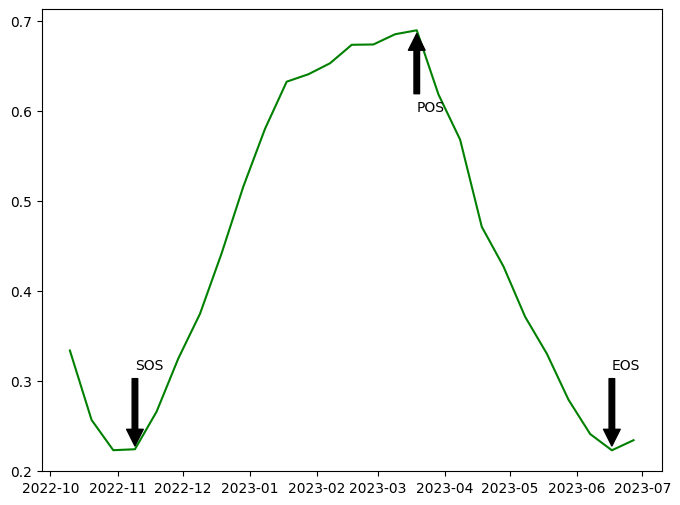

In [17]:
fig, ax = plt.subplots(figsize=(8,6))

y = veg_smooth_1D
x = veg_smooth_1D.time

line, = ax.plot(x,y, color='green')
ax.annotate('SOS', xy=(df.SOS[0], df.Trough[0]), xytext=(df.SOS[0], df.Trough[0]+0.09),
            arrowprops=dict(facecolor='black', shrink=0.05),)
ax.annotate('POS', xy=(df.POS[1], df.vPOS[1]), xytext=(df.POS[1], df.vPOS[1]-0.09),
            arrowprops=dict(facecolor='black', shrink=0.05),)
ax.annotate('EOS', xy=(df.EOS[1], df.vEOS[1]), xytext=(df.EOS[1], df.vEOS[1]+0.09),
            arrowprops=dict(facecolor='black', shrink=0.05),)
plt.show()

## Load dekadal evapotranspiration

In [18]:
period = [pd.to_datetime(df.SOS)[0], pd.to_datetime(df.EOS)[1]]
variable = 'L3-AETI-D'

aetid = wapor_map(region, variable, period, folder, extension = '.nc')

aetid_xr = load_wapor_ds(filename=aetid, variable=variable)

aetid_xr

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 23 files for L3-AETI-D.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset>
Dimensions:      (x: 488, y: 548, time: 23)
Coordinates:
  * x            (x) float64 3.372e+05 3.372e+05 ... 3.469e+05 3.469e+05
  * y            (y) float64 3.409e+06 3.409e+06 ... 3.398e+06 3.398e+06
    spatial_ref  int32 32636
  * time         (time) datetime64[ns] 2022-11-01 2022-11-11 ... 2023-06-11
Data variables:
    L3-AETI-D    (time, y, x) int16 11 11 12 11 11 11 11 ... 38 45 43 35 29 29
Attributes:
    long_name:            Actual EvapoTranspiration and Interception
    overview:             NONE
    scale_factor:         0.1
    temporal_resolution:  Dekad
    units:                mm/day
    _FillValue:           -9999
    add_offset:           0.0

In [19]:
# Reproject data
aetid_xr_reprojected = aetid_xr.odc.reproject(how=ds.odc.geobox, resampling="average")

#Set nodata to `NaN`
aetid_xr_reprojected = mask_invalid_data(aetid_xr_reprojected)
aetid_xr_reprojected

<xarray.Dataset>
Dimensions:      (time: 23, y: 551, x: 483)
Coordinates:
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 2022-11-01 2022-11-11 ... 2023-06-11
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
Data variables:
    L3-AETI-D    (time, y, x) float32 nan nan nan nan nan ... nan nan nan nan

In [20]:
aetid_xr_crop = aetid_xr_reprojected.where(cm == 1)

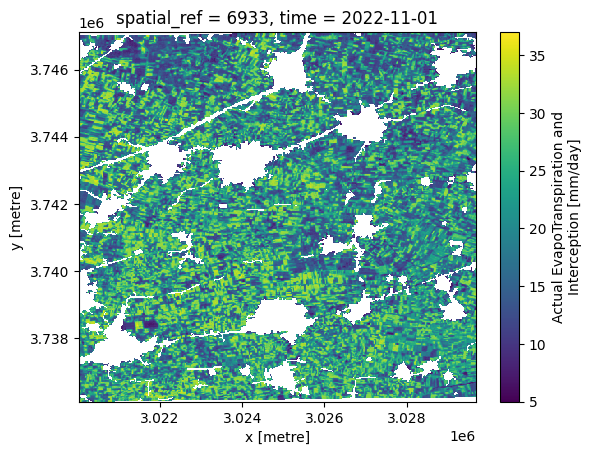

In [21]:
aetid_xr_crop['L3-AETI-D'].isel(time=0).plot()

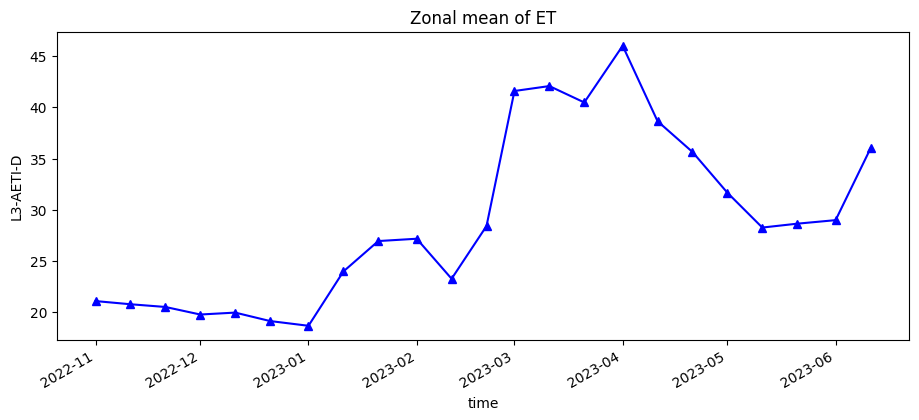

In [22]:
aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]).plot.line("b-^", figsize=(11, 4))
plt.title("Zonal mean of ET");

## Load dekadal Net Primary Productivity

In [23]:
variable = 'L3-NPP-D'

nppd = wapor_map(region, variable, period, folder, extension = '.nc')

nppd_xr = load_wapor_ds(filename=nppd, variable=variable)

# Reproject data
nppd_xr_reprojected = xr_reproject(src=nppd_xr,
                              geobox=ds.geobox,
                              resampling="average")

#Set nodata to `NaN`
nppd_xr_reprojected = mask_invalid_data(nppd_xr_reprojected)

nppd_xr_crop = nppd_xr_reprojected.where(cm == 1)

nppd_xr_crop

INFO: Given `region` matches with `ENO` L3 region.
INFO: Found 23 files for L3-NPP-D.
INFO: Converting from `.tif` to `.nc`.


<xarray.Dataset>
Dimensions:      (time: 23, y: 551, x: 483)
Coordinates:
  * y            (y) float64 3.747e+06 3.747e+06 ... 3.736e+06 3.736e+06
  * x            (x) float64 3.02e+06 3.02e+06 3.02e+06 ... 3.03e+06 3.03e+06
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 2022-11-01 2022-11-11 ... 2023-06-11
Data variables:
    L3-NPP-D     (time, y, x) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

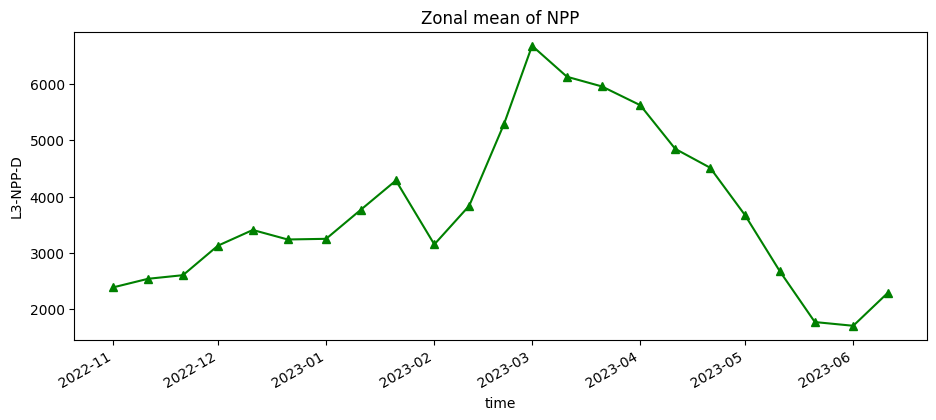

In [24]:
nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]).plot.line("g-^", figsize=(11, 4))
plt.title("Zonal mean of NPP");

## Combine variables into one plot

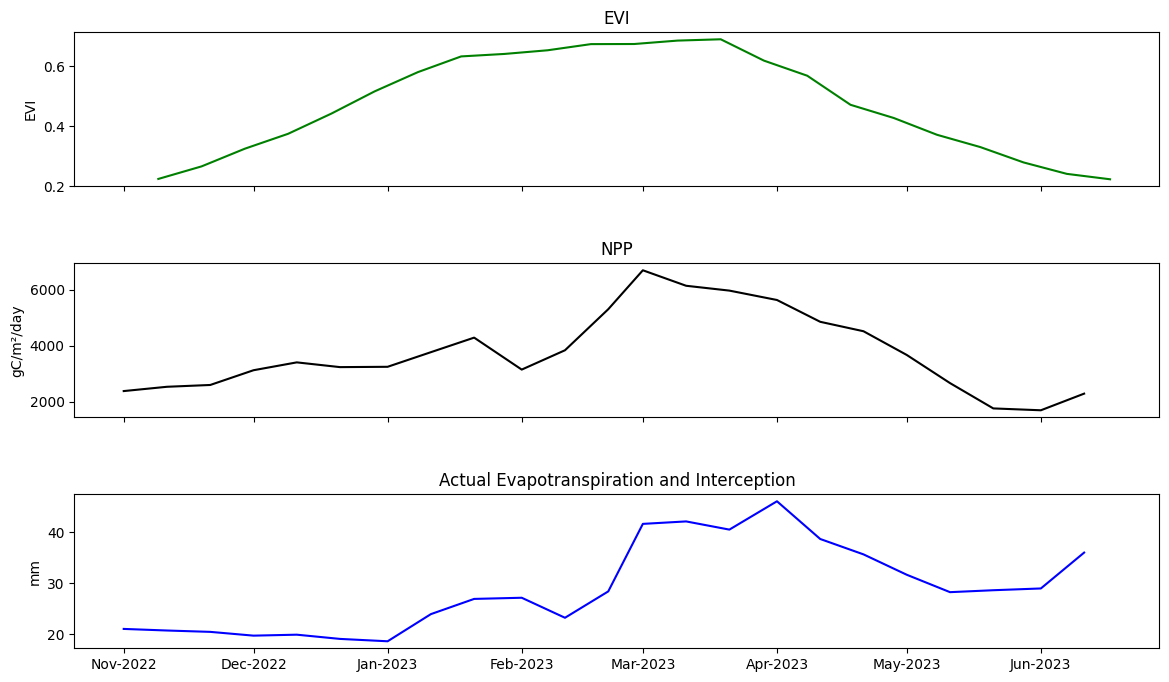

In [25]:
fig, axs = plt.subplots(3, sharex=True, figsize=(14,8), gridspec_kw={'hspace': 0.5})

veg_smooth_1D_slice = veg_smooth_1D.sel(time=slice(*period))

axs[0].set_title('EVI')
axs[0].set_ylabel('EVI')
axs[0].plot(veg_smooth_1D_slice.time, veg_smooth_1D_slice, color='green')

axs[1].set_title('NPP')
axs[1].set_ylabel('gC/m²/day')
axs[1].plot(nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]).time, nppd_xr_crop['L3-NPP-D'].mean(["x", "y"]), color='black')

axs[2].set_title('Actual Evapotranspiration and Interception')
axs[2].set_ylabel('mm')
axs[2].plot(aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]).time, aetid_xr_crop['L3-AETI-D'].mean(["x", "y"]), color='blue')
axs[2].xaxis_date()
axs[2].xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

## Conclusion

This notebook demonstrated using WaPOR through a crop season and integrating it with phenology tools.

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:** 

In [26]:
print(datacube.__version__)

1.8.15


**Last Tested:**

In [27]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2024-08-09'